In [143]:
import warnings
warnings.filterwarnings("ignore")

from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
# from langchain_hub import hub

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition

from langchain_community.document_loaders import WebBaseLoader

from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool

from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [144]:
import os
from dotenv import load_dotenv
load_dotenv()
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
HF_TOKEN=os.getenv("HUGGINGFACE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"]= GROQ_API_KEY
os.environ["HF_TOKEN"] = HF_TOKEN

In [145]:
from langchain_openai import ChatOpenAI

In [146]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# llm = ChatOpenAI(
#     # Point to the OpenAI-compatible "door"
#     base_url="http://localhost:11434/v1", 
    
#     # Required but ignored by Ollama
#     api_key="ollama", 
    
#     # The exact name you see in 'ollama list'
#     model="qwen2.5:1.5b", 
#     temperature=0
# )

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", api_key=os.getenv("GOOGLE_API_KEY"))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8477.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# llm.invoke("hello how are you?")

AIMessage(content="Hello! I'm just a computer program and don't have feelings, but thank you for asking how I am. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 34, 'total_tokens': 65, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2.5:1.5b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-635', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d4358-6a96-7f50-bfa6-f92857da3533-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 31, 'total_tokens': 65, 'input_token_details': {}, 'output_token_details': {}})

In [38]:
llm

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002575BBAABA0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002575BBAB620>, root_client=<openai.OpenAI object at 0x000002575BBA81A0>, root_async_client=<openai.AsyncOpenAI object at 0x000002575BBAB380>, model_name='qwen2.5:1.5b', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='http://localhost:11434/v1')

In [6]:
# url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [7]:
# WebBaseLoader(url).load()

In [8]:
# WebBaseLoader(url).load()[0].metadata

In [147]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [148]:
docs = [WebBaseLoader(url).load() for url in urls]

In [65]:
# docs

In [149]:
docs_list=[item for sublist in docs for item in sublist]

In [150]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=350, chunk_overlap=25)

In [151]:
doc_splits=text_splitter.split_documents(docs_list)

In [152]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [153]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chrome",
    embedding=embeddings    
)

In [154]:
retriever=vectorstore.as_retriever()

In [155]:
# print(retriever.invoke("What is a Prompt engineering?"))

In [156]:
retriever_tool=create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
    )

In [157]:
tools=[retriever_tool]

In [158]:
retrieve=ToolNode([retriever_tool])

Certainly! Let's break down the code:

### **Code Breakdown:**

```python
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
```

This code defines a class `AgentState` that is a **`TypedDict`**, which is a special kind of dictionary with fixed keys and value types, used to provide better type safety and autocompletion in Python.

Here’s a breakdown of each part:

---

### **1. `AgentState(TypedDict)`**
- **`TypedDict`**: This is a special class provided by `typing` that allows you to define dictionaries where each key has a fixed type. The dictionary keys are usually predefined, and each key must have a specified type.

  - `AgentState` here is a subclass of `TypedDict`, meaning `AgentState` will represent a dictionary where the types of its values are enforced.

  - Example:
    ```python
    agent_state = AgentState(messages=["Message 1", "Message 2"])  # This would be valid.
    ```

---

### **2. `messages: Annotated[Sequence[BaseMessage], add_messages]`**
- **`messages`**: This is a key in the `AgentState` dictionary. It holds a sequence (like a list or tuple) of `BaseMessage` objects.
  
- **`Annotated[...]`**: `Annotated` is used to attach additional metadata or annotations to the type. It’s a way to add extra information to the type system without affecting the actual type. In this case, it provides metadata for the `messages` field. 

  - The **`Annotated`** wrapper allows you to define a type and also include additional information that might be used by tools like static analyzers or for other purposes like validation.

- **`Sequence[BaseMessage]`**: This indicates that `messages` should be a sequence (e.g., a list or tuple) of `BaseMessage` objects.

  - **`BaseMessage`** is likely a class that represents a message in the context of your program. It could have fields like `content`, `sender`, `timestamp`, etc.
  
- **`add_messages`**: This is a special annotation (or metadata) that likely refers to some function or constant that’s being added as additional context. The specific role of `add_messages` will depend on how it's defined elsewhere in the codebase.

  - **`add_messages`** could be a function, validator, or modifier that helps manage or process the messages in some way, but it's not directly modifying the type of `messages`. It's simply metadata for the type checker or other parts of the system.

  - For example, if `add_messages` were a function, it could be used in a custom decorator, validation system, or simply as an indication of how to handle messages.

---

### **Putting It All Together:**

- **`AgentState`** is a dictionary where one of the keys, `messages`, is specifically typed to be a **sequence of `BaseMessage`** objects. The sequence is annotated with **`add_messages`**, which provides additional metadata but doesn’t affect the type directly.
  
- **Example of `AgentState` usage:**

```python
from typing import TypedDict, Sequence
from typing_extensions import Annotated

class BaseMessage:
    def __init__(self, content: str):
        self.content = content

# Defining the `AgentState` TypedDict
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], "add_messages"]

# Example usage
message1 = BaseMessage("Hello, world!")
message2 = BaseMessage("How are you?")
state = AgentState(messages=[message1, message2])

print(state)
```

In the above code:
- `AgentState` is a dictionary with a `messages` field that is a sequence of `BaseMessage` objects.
- `add_messages` is metadata associated with the `messages` field, which can help guide the usage or interpretation of the data.

---

### **Summary:**
- `AgentState` is a dictionary where the `messages` key holds a sequence of `BaseMessage` objects.
- `Annotated[Sequence[BaseMessage], add_messages]` means that `messages` is a sequence of `BaseMessage` objects with additional metadata (`add_messages`).
- The annotation `add_messages` provides extra context or metadata that doesn't alter the type directly but can be used for purposes like validation or other system-specific behavior.

Let me know if you'd like further clarification on any part of this! 😊

In [159]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [160]:
llm_with_tool = llm.bind_tools(tools)

In [161]:
query = "What is a Autonomous Agent?"

In [126]:
print(llm_with_tool.invoke(query))

content=[{'type': 'text', 'text': 'An autonomous agent is an entity that can act independently in an environment to achieve its goals. It can perceive its surroundings, make decisions, and execute actions without constant human intervention. These agents often employ AI techniques like machine learning and planning to learn and adapt their behavior.', 'extras': {'signature': 'Cs8DAb4+9vswpL2+OrOx94zoaQpwtALu6Ij28vqa6tvm1njcjTq2xjssOH7O5w9DSMXdgcQGJXB/0wg5meTipZgPtUUljmk/g2G/sD5TqFOsky3l+4rbO7OCvsV1smZsqxInARScq0dWo0MteSbKexI90lSCj3icBV3G1vkai1biBFjdUwvLCCHP+WpGww04lWqJu4JzeWstNnBv0+xbhHvUmeCR8FPAOLvOZoBumJaiv2F4XZ1P6OEb8/D723jmBw/FSKZ9tDuq/s7GkGRV5eJrDqrqj7msQhNPiPIT3D8fg9sfic+jLe1BObK4agX/9tTCr3Pea5/FdfNV1EAyPu4cM+28uQZ/NlZpeiviGAbC38D+o9SVBBTBHWOmjMHHKd0LntKF9ur5n7HoW2ZXCgfe12WVEIQCp+FN0KQUi0IqDHBWYL5bik+b00qIRYX1FvJ4ijGbjucAGxUaGx3xNSOpfCdrJBR2GBf7GqITS8H/IAi3BCUIuTQkKfTgH1a1YdMz0NOHwS60jUWNd+5E+j5AXORZNxRKh2Yptl7/lmWj5KzZ7gnFwjAmottdyr2ufuUz0XQdk1C89hwz3pD0JjWvdwsKunTbxjX1EmK4yUkIS

In [127]:
# content=[{'type': 'text', 'text': 'An autonomous agent is an entity that can perceive its environment, make decisions, and take actions without constant human intervention. These agents are designed to operate independently to achieve specific goals. They often incorporate elements of artificial intelligence, machine learning, and control systems to exhibit intelligent behavior and adapt to changing circumstances.', 'extras': {'signature': 'CpgEAb4+9vuCkyS5NzcMIjaVaTB/QKN01klFluk5sMQgl6odZu7dUIrmt9ma72qUTJvbTgZqWU06/6Dw+XUhv2ObdEzTNSCGDAqWT8bTKqMH4ufOdsIFjKDcNuj6hhIa2ifXVgHqVSMwnQOiXA9hr03asEsH3DUKCvxY+S88OePQH2JPUbP6w/jdIONzj80QG06Y0XsqwagrJ5vKfrOyP1gkeMr7O2eNe9QAA3CagsKrKs1ab4bQT7/gBlG4fA4futiPwz3veJTN1hbAALK3xSxqr4AY3j9nBPdhYkOUa9bd1bxpi4DmofrtjyRZ9f8PhKO5L7YbJYdvQHmPW4/ZS9vcOjRBvVNmB/IDPL0o2nKthg9NjcZSPshkyeopvj9ZSqz8Os1davzZcUCEbPOgxNoTm2MpitNfr1RJ5EYPU7H/5zxgET/9wfCsaUu0JfJnfo0dvLQCAlPo1imUcLSunlHGIkFj0m/eQ+s8G9GEFXkg7kF3Jys9bKSUtkfCQJ9j9+bQqK4J6ZUFdVjQKubVSK4VjGt/n3wljJx1v3YKN7TKQhLQPHoGE+brccKLBrxAHVpaVsw7Bx703+U6EF1rIDu5miAPGxeG9pBTw5LDxqcpkuBve7u5nhdT0uFtdl5I4pDPzpJKNtO7y1nNNH4ZLL5PdawLR7muU5+MXINbILipcRKRlTSjqsyhdtqP9MgJfRh4gtJ4YvOIRBk='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d43cd-5e9c-7231-ba43-93c5baa9f50d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 133, 'output_tokens': 170, 'total_tokens': 303, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 111}}

In [162]:
def ai_assistant(state:AgentState):
    print("---CALL AGENT---")
    messages = state['messages']
    
    # Ensure we have a HumanMessage if first message is just a string
    if messages and isinstance(messages[0], str):
        from langchain_core.messages import HumanMessage
        messages = [HumanMessage(content=messages[0])]
    
    llm_with_tool = llm.bind_tools(tools)
    response = llm_with_tool.invoke(messages)
    
    print(f"Response has tool_calls: {bool(response.tool_calls)}")
    if response.tool_calls:
        print(f"Tool calls: {response.tool_calls}")
    
    return {"messages": [response]}

In [163]:
class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [164]:
def grade_documents(state:AgentState)->Literal["Output_Generator", "Query_Rewriter"]:
    print("---GRADING DOCUMENTS---")
    llm_with_structure_op=llm.with_structured_output(grade)
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user's question.
                    Here is the document: {context}
                    Here is the user's question: {question}
                    If the document talks about or contains information related to the user's question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
    chain = prompt | llm_with_structure_op
    
    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    
    # Debug: Check message structure
    print(f"Last message type: {type(last_message)}")
    print(f"Last message: {last_message}")
    
    # Extract docs - handle ToolMessage structure
    docs = last_message.content if hasattr(last_message, 'content') else str(last_message)
    
    if not docs:
        print("---ERROR: No document content found---")
        return "rewriter"
    
    print(f"Question: {question}")
    print(f"Document preview: {docs[:300] if len(docs) > 300 else docs}")
    
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter"

In [165]:
def generate(state:AgentState):
    print("---GENERATE---")
    messages = state["messages"]

    question = messages[0].content if hasattr(messages[0], 'content') else str(messages[0])
    
    last_message = messages[-1]
    docs = last_message.content if hasattr(last_message, 'content') else str(last_message)
    
    print(f"Generating answer for: {question}")
    print(f"Using docs: {docs[:300] if len(docs) > 300 else docs}")
    
    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
        Question: {question} 
        Context: {context} 
        Answer:""",
        input_variables=["question", "context"]
    )

    
    rag_chain = prompt | llm

    response = rag_chain.invoke({"context": docs, "question": question})
    print(f"Response generated: {response.content if hasattr(response, 'content') else response}")
    
    return {"messages": [response]}

In [166]:
from langchain_core.messages import HumanMessage

def rewrite(state:AgentState):
    print("---REWRITING QUERY---")
    messages = state["messages"]
    question = messages[0].content if hasattr(messages[0], 'content') else str(messages[0])
    
    print(f"Original query: {question}")
    
    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response = llm.invoke(message)
    
    print(f"Rewritten query: {response.content if hasattr(response, 'content') else response}")
    
    return {"messages": [response]}

In [167]:
workflow=StateGraph(AgentState)
workflow.add_node("My_Ai_Assistant",ai_assistant)
workflow.add_node("Vector_Retriever", retrieve) 
workflow.add_node("Output_Generator", generate)
workflow.add_node("Query_Rewriter", rewrite) 

In [168]:
workflow.add_edge(START,"My_Ai_Assistant")

In [169]:
workflow.add_conditional_edges("My_Ai_Assistant",
                            tools_condition,
                            {"tools": "Vector_Retriever",
                                END: END,})

In [170]:
workflow.add_conditional_edges("Vector_Retriever",
                            grade_documents,
                            {"generator": "Output_Generator",
                            "rewriter": "Query_Rewriter"
                            }
                            )

In [171]:
workflow.add_edge("Output_Generator", END)

In [172]:
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")

In [173]:
app=workflow.compile()

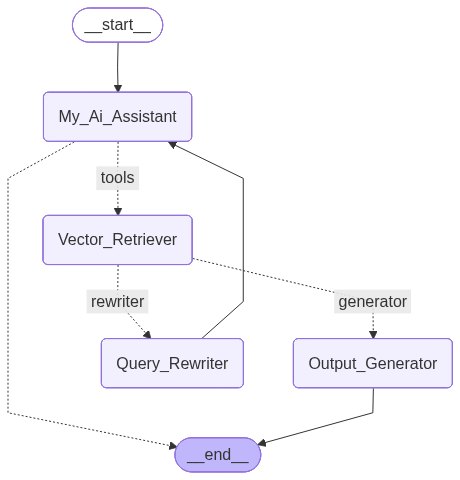

In [174]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [175]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

---CALL AGENT---
Response has tool_calls: True
Tool calls: [{'name': 'retrieve_blog_posts', 'args': {'query': 'Autonomous Agent'}, 'id': '5b7a20af-e5af-4c05-be0d-768ec1c0aab0', 'type': 'tool_call'}]
---GRADING DOCUMENTS---
Last message type: <class 'langchain_core.messages.tool.ToolMessage'>
Last message: content="LLM Powered Autonomous Agents | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerati

{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='c3b70a73-1e3f-4d99-98c5-9839b5721228'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'retrieve_blog_posts', 'arguments': '{"query": "Autonomous Agent"}'}, '__gemini_function_call_thought_signatures__': {'5b7a20af-e5af-4c05-be0d-768ec1c0aab0': 'CukDAb4+9vsmg7mJzeeyt/ptUNaif2i0fUHkMHoycQ92CDdVOxkVHjd2nYPyEuBwCbuKMOQx6mqu9zwoZbEfEZNyR8D1DuTTWpy8hXgtz0xfOZoHcHDvzYjHin4dPXzNXujQM/xIukqxZg/7Dez5EGCsYvBcwQ8PA6vF8dyBvnBuvnLmJvqLKB9jQWXbgmEeDfPo6+OgnX9u/jcGo8kGf9z1sh2CymF53bSOuuw/PuWjqxg8jEzBG2OuzV7nkDelMOjms5ngW3Dx/3rL2JfZM3wcpFeI2Y2IbGo/y5SgOA0lrrY7YuUGvHbcgjTk9KAMCMhTyA1w8OXO/RZiwxz9tHEeXF3ZpGd1P70VRpB0mEziWp9TRR2VV1BIQ9KbiCQ9C9Dd7VqV5Ty0j/9oN26eWH2LSySIuGflxzHA9r9z565j+UJqn1E3zTBcdLSDpp5FaQOu/XcaOrZ1+Sth9MzB7ztxKJqUGt3F+cofBpUFZ7I2PYOpSxUncee2Vv5MO4ZBqOT3lCe0NULJTTpmTpgZm0K2cDS6mgZZ7Zix5JIhAAYSGCFrqfyqN4Yj+BC4QTXyncozhrlw8NDBC3GoPVKiVzAODzh9MWmdClRUPoiPEJ

In [177]:
app.invoke({"messages":["what is a prompt engineering explain me in terms of agents and langchain?"]})

---CALL AGENT---
Response has tool_calls: True
Tool calls: [{'name': 'retrieve_blog_posts', 'args': {'query': 'prompt engineering agents langchain'}, 'id': 'd04f64a4-819e-4424-8418-ab435c6b9b7f', 'type': 'tool_call'}]
---GRADING DOCUMENTS---
Last message type: <class 'langchain_core.messages.tool.ToolMessage'>
Last message: content="OpenAI Cookbook has many in-depth examples for how to utilize LLM efficiently.\nLangChain, a library for combining language models with other components to build applications.\nPrompt Engineering Guide repo contains a pretty comprehensive collection of education materials on prompt engineering.\nlearnprompting.org\nPromptPerfect\nSemantic Kernel\n\nOpenAI Cookbook has many in-depth examples for how to utilize LLM efficiently.\nLangChain, a library for combining language models with other components to build applications.\nPrompt Engineering Guide repo contains a pretty comprehensive collection of education materials on prompt engineering.\nlearnprompting.or

{'messages': [HumanMessage(content='what is a prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='f406e36a-58e9-4c38-9e32-431db16cca63'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'retrieve_blog_posts', 'arguments': '{"query": "prompt engineering agents langchain"}'}, '__gemini_function_call_thought_signatures__': {'d04f64a4-819e-4424-8418-ab435c6b9b7f': 'CrMDAb4+9vvFtIuQFIm/em87xm8zS5cuIthTo2Ya//aqZOYJ5X06LLzD0OArNeJUQvsoCmQyjOQefoCyWOCB3jMwcTIzAFg4r+5vB9BMwb+Bp4qVA+7FDsojhignynnoVNzE/5AuClpgIoq3GiCCMUq4Kx/nn+x9aitadd2lN44tgfmH7I8e42/q88mqVpdw9gwlwrTeDILla02CbmrgdIzr0lHyYQKObykScq12+xn5FkBpGZBARpu5kG4an8LNdYNg49I4RZEEaZCJwjKWomydg9dybWHI0GcTilQmHXs5LN//BVv9NUc/yDx+qe7ZnBXgrHxf0HrPpwnzn3ZACm86P0UEeTY9+94IR0b2etYNninF+LMm3AkV7lOc6FBDQXXY1seOckjGhzED77euOiIZTZSYrbsD8IPj9vLpqvMYOzyATkcsdoZf35zEGaODexXuWHjbuHbnmEImxaMQiq8MOMqYclXMMuXe2VD8VBCoJ3nGSBu+mqOGmE2TAL56xUs4wVFjpel9Tz/UsEKf8gtnausstjKuzY0PAf/mw

In [176]:
app.invoke({"messages":["what is capital of india?"]})

---CALL AGENT---
Response has tool_calls: False


{'messages': [HumanMessage(content='what is capital of india?', additional_kwargs={}, response_metadata={}, id='37a4854f-775d-41e1-a903-83c218d53bc5'),
  AIMessage(content="I am sorry, I cannot answer that question. My knowledge base is limited to Lilian Weng's blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs. ", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d455e-2393-7413-b1a0-d298cef547cd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'input_token_details': {'cache_read': 0}})]}